In [1]:
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import os

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline
)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:
# Загружаем датасет
dataset = load_dataset("dair-ai/emotion")

print("Размеры split-частей:")
for split in dataset:
    print(f"  {split}: {len(dataset[split])}")

# Словари маппинга
label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
label2id = {l: i for i, l in enumerate(label_names)}
id2label = {i: l for l, i in label2id.items()}

# 3 примера текстов и меток
print("\n3 примера из train:")
for i in range(3):
    row = dataset["train"][i]
    print(f"[{id2label[row['label']]}] {row['text']}")

'[WinError 10051] Сделана попытка выполнить операцию на сокете при отключенной сети' thrown while requesting HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/cab853a1dbdf4c42c2b3ef2173804746df8825fe/emotion.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since dair-ai/emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at C:\Users\Mi\.cache\huggingface\datasets\dair-ai___emotion\split\0.0.0\cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Sun Apr  5 15:07:13 2026).


Размеры split-частей:
  train: 16000
  validation: 2000
  test: 2000

3 примера из train:
[sadness] i didnt feel humiliated
[sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
[anger] im grabbing a minute to post i feel greedy wrong


Классифицируются короткие английские тексты (сообщения из соцсетей) на 6 эмоциональных категорий (sadness, joy, love, anger, fear, surprise).

In [3]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

demo_texts = [
    "I'am feel so happy today!",
    "This is the worst day ever.",
    "What a surprising gift!"
]

print("Разбор токенизации для 3 текстов:")
for txt in demo_texts:
    enc = tokenizer(txt, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(enc.input_ids[0])
    print(f"\nОригинал: '{txt}'")
    print(f"  Токены: {tokens}")
    print(f"  input_ids: {enc.input_ids[0].tolist()}")
    print(f"  attention_mask: {enc.attention_mask[0].tolist()}")
    print(f"  Special tokens: [CLS] (id 101), [SEP] (id 102)")

# Пример padding/truncation
batch = tokenizer(
    ["Short text", "This is a slightly longer text that we want to truncate if needed but keep it under 128 tokens."],
    padding=True, truncation=True, max_length=128, return_tensors="pt"
)
print(f"\nДемонстрация padding (batch_size=2, max_length=128):")
print(f"  Форма input_ids после padding: {batch.input_ids.shape}")

Разбор токенизации для 3 текстов:

Оригинал: 'I'am feel so happy today!'
  Токены: ['[CLS]', 'i', "'", 'am', 'feel', 'so', 'happy', 'today', '!', '[SEP]']
  input_ids: [101, 1045, 1005, 2572, 2514, 2061, 3407, 2651, 999, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Special tokens: [CLS] (id 101), [SEP] (id 102)

Оригинал: 'This is the worst day ever.'
  Токены: ['[CLS]', 'this', 'is', 'the', 'worst', 'day', 'ever', '.', '[SEP]']
  input_ids: [101, 2023, 2003, 1996, 5409, 2154, 2412, 1012, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]
  Special tokens: [CLS] (id 101), [SEP] (id 102)

Оригинал: 'What a surprising gift!'
  Токены: ['[CLS]', 'what', 'a', 'surprising', 'gift', '!', '[SEP]']
  input_ids: [101, 2054, 1037, 11341, 5592, 999, 102]
  attention_mask: [1, 1, 1, 1, 1, 1, 1]
  Special tokens: [CLS] (id 101), [SEP] (id 102)

Демонстрация padding (batch_size=2, max_length=128):
  Форма input_ids после padding: torch.Size([2, 25])


In [5]:
# Готовая модель для классификации эмоций
ready_model_name = "cardiffnlp/twitter-roberta-base-emotion"
ready_tokenizer = AutoTokenizer.from_pretrained(ready_model_name)
ready_model = AutoModelForSequenceClassification.from_pretrained(ready_model_name)

# return_all_scores убран, так как в новых transformers он часто игнорируется
ready_pipe = pipeline(
    "text-classification",
    model=ready_model,
    tokenizer=ready_tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

test_texts_ready = [
    "I am absolutely thrilled with the results!",
    "I hate waiting in long lines.",
    "Oh no, something broke down again."
]

print("Инференс готовой модели (3 примера):")
for txt in test_texts_ready:
    # pipeline всегда возвращает список результатов. Берём первый (и единственный) элемент.
    preds = ready_pipe(txt)[0]
    
    # Обработка разных форматов вывода: dict (новая версия) или list[dict] (старая)
    if isinstance(preds, dict):
        top_pred = preds
    else:
        top_pred = max(preds, key=lambda x: x['score'])
        
    # Убираем префикс модели (например, 'joy' из 'LABEL_joy')
    label = top_pred['label'].split('_')[-1] if '_' in top_pred['label'] else top_pred['label']
    print(f"'{txt}' -> {label} ({top_pred['score']:.3f})")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-emotion
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Инференс готовой модели (3 примера):
'I am absolutely thrilled with the results!' -> optimism (0.922)
'I hate waiting in long lines.' -> joy (0.962)
'Oh no, something broke down again.' -> sadness (0.969)


Готовая модель работает удовлетворительно и может различать 6 базовых эмоций в простых текстах, но может давать смещённые предсказания на контекстных или ироничных текстах.

In [6]:
# Токенизация датасета
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Загружаем базовую модель для fine-tuning
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

# Параметры обучения
common_kwargs = dict(
    output_dir="outputs/HW13",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none"
)

try:
    training_args = TrainingArguments(eval_strategy="epoch", save_strategy="epoch", **common_kwargs)
except TypeError:
    training_args = TrainingArguments(evaluation_strategy="epoch", save_strategy="epoch", **common_kwargs)

try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

print("Запуск fine-tuning...")
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Запуск fine-tuning...


C:\Users\Mi\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.219134,0.192396,0.930000,0.903376
2,0.111913,0.156572,0.934000,0.907834
3,0.092368,0.148193,0.944000,0.920022


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Mi\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.24001660871505737, metrics={'train_runtime': 2544.9015, 'train_samples_per_second': 18.861, 'train_steps_per_second': 1.179, 'total_flos': 584777647046016.0, 'train_loss': 0.24001660871505737, 'epoch': 3.0})

In [7]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

C:\Users\Mi\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Mi\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.1482
eval_accuracy: 0.9440
eval_f1_macro: 0.9200
eval_runtime: 24.4825
eval_samples_per_second: 81.6910
eval_steps_per_second: 5.1060
epoch: 3.0000

Test metrics:
eval_loss: 0.1657
eval_accuracy: 0.9285
eval_f1_macro: 0.8828
eval_runtime: 24.6967
eval_samples_per_second: 80.9830
eval_steps_per_second: 5.0610
epoch: 3.0000


C:\Users\Mi\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✅ Файл 'sample_predictions.csv' сохранен (включая confidence)


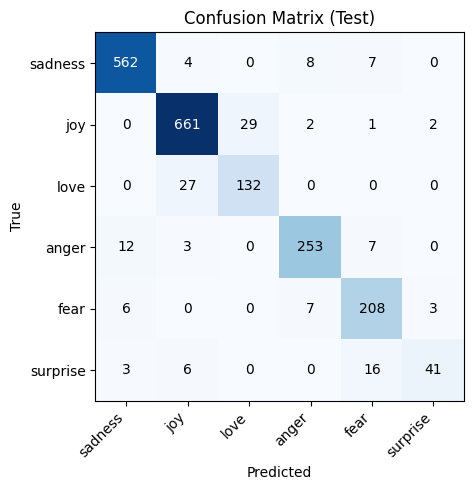


5 примеров предсказаний модели:


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.999103
1,im updating my blog because i feel shitty,sadness,sadness,0.999195
2,i never make her separate from me because i do...,sadness,sadness,0.999185
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.999116
4,i was feeling a little vain when i did this one,sadness,sadness,0.999214



Примеры ошибок модели:


,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.832898
40,i feel if i completely hated things i d exerci...,anger,sadness,0.573216
67,i feel a bit stressed even though all the thin...,anger,sadness,0.674564
72,i am right handed however i play billiards lef...,surprise,fear,0.777773
86,i feel like i am in paradise kissing those swe...,joy,love,0.812784


In [8]:
# 2. Получение предсказаний для анализа
predictions = trainer.predict(tokenized_datasets["test"])
test_preds = np.argmax(predictions.predictions, axis=-1)
test_true = predictions.label_ids
probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
confidences = np.max(probs, axis=1)

test_df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": [id2label[l] for l in test_true],
    "pred_label": [id2label[l] for l in test_preds],
    "confidence": confidences        
})

#Сохраняем артефакты в папку artifacts/
os.makedirs("artifacts", exist_ok=True)

# Сохраняем CSV
test_df.to_csv("artifacts/sample_predictions.csv", index=False)
print("\n✅ Файл 'sample_predictions.csv' сохранен (включая confidence)")

#Матрица ошибок
cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test)")
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45, ha='right')
plt.yticks(tick_marks, label_names)
for i in range(len(label_names)):
    for j in range(len(label_names)):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

# 4. 5 примеров предсказаний
test_df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": [id2label[l] for l in test_true],
    "pred_label": [id2label[l] for l in test_preds],
    "confidence": confidences
})
print("\n5 примеров предсказаний модели:")
display(test_df.head())

# 5. Краткий анализ ошибок
errors = test_df[test_df["true_label"] != test_df["pred_label"]].head(5)
print("\nПримеры ошибок модели:")
display(errors)

Модель иногда путает 'joy' и 'love', так как оба класса содержат сильную позитивную лексику. Также встречаются ошибки на текстах с неоднозначным контекстом, где эмоциональная окраска зависит от предыдущих сообщений пользователя.